# Toy models for parameter estimation

**Day 2, 14:30 — 30 minutes.** Alexander Fengler.

This session is the bridge. At 12:00 you built models in PyMC. At 14:00 you
simulated from cognitive models. Now we put the two together: **a
drift-diffusion likelihood dropped straight into a PyMC model**, fitted the
way you already know how to fit things.

We will not explain *how* the DDM likelihood works — that is tomorrow. Today
it is simply a distribution you can use, exactly like `pm.Normal`.

The shape of this session is a *miniature scientific workflow*.

<details class="sbi-note">
<summary>▶️ <b>Running this on Google Colab</b></summary>

The cell below is a no-op on your own machine. On Colab it installs the stack
and downloads the shared helper module, which lives one directory up in the
repository and is therefore not importable there.

Expect the install to take a few minutes. If Colab asks you to restart the
runtime, do it and then run the cell again — the second run is a no-op.

</details>

In [1]:
# --- Google Colab bootstrap; does nothing anywhere else ---------------------
import importlib.util, subprocess, sys, urllib.error, urllib.request

IN_COLAB = importlib.util.find_spec("google.colab") is not None

# `main` once this is merged; the branch is the fallback so the Colab path can
# be tested BEFORE the merge, when main does not yet have these files.
_REFS = ("main", "afengler.tutorials")
_RAW = "https://raw.githubusercontent.com/stefanradev93/sbi4cogsci/{ref}/tutorials/"


def _fetch(module):
    for ref in _REFS:
        try:
            urllib.request.urlretrieve(_RAW.format(ref=ref) + module, module)
            return ref
        except urllib.error.HTTPError:
            continue
    raise RuntimeError(f"could not fetch {module} from any of {_REFS}")


if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pymc>=6.2", "arviz>=1.2", "hssm>=0.4"],
                   check=True)
    for _mod in ["sbi4cogsci_style.py"]:
        print(f"  fetched {_mod} from {_fetch(_mod)}")
    print("Colab setup done.")

In [2]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

from ssms import Simulator
from hssm.likelihoods import DDM        # <- the DDM as a PyMC distribution
from hssm.likelihoods import logp_ddm   # the same likelihood, callable directly

RANDOM_SEED = sum(map(ord, "sbi4cogsci-toy"))
rng = np.random.default_rng(RANDOM_SEED)

# Four chains, run in parallel. `r_hat` compares variance *between* chains to
# variance *within* them, so two chains make it a weak test — ArviZ warns about
# exactly this. Four chains on four cores also finishes sooner than two chains
# run one after another, so this is cheaper as well as better.
DRAWS, TUNE, CHAINS = 800, 800, 4
CORES = 4

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## 1. The data

A two-alternative decision task. Every trial has two design features:

- **coherence** — how much evidence the stimulus carries: `low`, `medium`, `high`
- **emphasis** — the instruction given: respond `speed`-fast or `accuracy`-carefully

250 trials in each of the six cells, so 500 trials per coherence level and
1500 in total. This is a synthetic dataset: something specific generated it,
and by the end of the session you will know what.

In [3]:
CONDITIONS = ["low", "medium", "high"]
EMPHASES = ["speed", "accuracy"]
N_PER_CELL = 250

# --- the generating process (do not peek at the values until section 5) ------
_V_BY_COHERENCE = {"low": 0.35, "medium": 0.85, "high": 1.5}
_A_BY_EMPHASIS = {"speed": 0.9, "accuracy": 1.6}
_Z_TRUE, _T_TRUE = 0.5, 0.30

rows = []
for i, coh in enumerate(CONDITIONS):
    for j, emp in enumerate(EMPHASES):
        theta = [_V_BY_COHERENCE[coh], _A_BY_EMPHASIS[emp], _Z_TRUE, _T_TRUE]
        # Seed from the cell's *position*, not `hash((coh, emp))`: Python salts
        # string hashes per process (PYTHONHASHSEED), so a hash-derived seed
        # silently draws a different dataset on every run.
        out = Simulator(model="ddm").simulate(
            theta=theta, n_samples=N_PER_CELL,
            random_state=RANDOM_SEED + 10 * i + j)
        rows.append(pd.DataFrame({
            "rt": out["rts"].flatten(),
            "response": out["choices"].flatten().astype(int),
            "coherence": coh,
            "emphasis": emp,
        }))

data = pd.concat(rows, ignore_index=True)
data["coherence"] = pd.Categorical(data["coherence"], categories=CONDITIONS, ordered=True)
data["emphasis"] = pd.Categorical(data["emphasis"], categories=EMPHASES)
print(data.head())
print(f"\n{len(data)} trials")

         rt  response coherence emphasis
0  0.450323         1       low    speed
1  1.173512        -1       low    speed
2  0.698440         1       low    speed
3  0.733633         1       low    speed
4  1.439245         1       low    speed

1500 trials


### Look before you fit

Two summaries answer most of the question: how *accurate* is each cell, and
how *fast*?

In [4]:
summary = (data.assign(correct=lambda d: d["response"] == 1)
               .groupby(["coherence", "emphasis"], observed=True)
               .agg(accuracy=("correct", "mean"), mean_rt=("rt", "mean"))
               .round(3))
print(summary.to_string())

                    accuracy  mean_rt
coherence emphasis                   
low       speed        0.680    1.149
          accuracy     0.724    2.614
medium    speed        0.844    1.013
          accuracy     0.956    1.955
high      speed        0.960    0.875
          accuracy     0.996    1.343


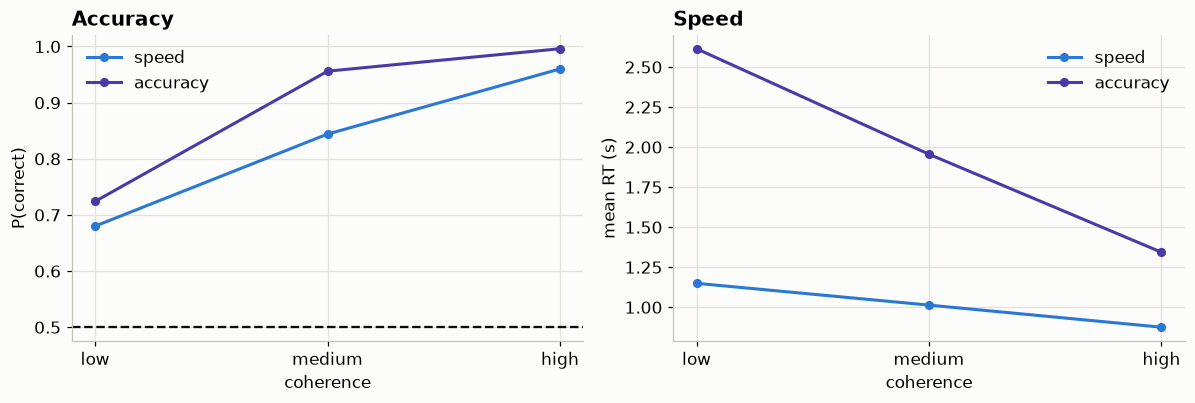

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(len(CONDITIONS))
for emp, colour in [("speed", S.PRIMARY), ("accuracy", S.NAIVE)]:
    sub = summary.xs(emp, level="emphasis")
    ax1.plot(x, sub["accuracy"], "o-", color=colour, label=emp)
    ax2.plot(x, sub["mean_rt"], "o-", color=colour, label=emp)
for ax, ylab, title in [(ax1, "P(correct)", "Accuracy"), (ax2, "mean RT (s)", "Speed")]:
    ax.set(xticks=x, xlabel="coherence", ylabel=ylab, title=title)
    ax.set_xticklabels(CONDITIONS)
    ax.legend()
S.truth_line(ax1, 0.5, label="chance")
fig.tight_layout()

Two patterns:

- Accuracy climbs steeply with coherence, and barely moves with emphasis.
- Mean RT is dominated by emphasis, and moves comparatively little with
  coherence.

A model with one drift rate and one boundary for the whole dataset cannot
produce that. Something has to vary — the question is *what*.

> **Poll.** Before fitting: which parameter should coherence affect?
>
> - **A.** Boundary separation $a$ — harder stimuli need more evidence.
> - **B.** Drift rate $v$ — coherence is how fast evidence accumulates.
> - **C.** Non-decision time $t$ — harder stimuli take longer to encode.
> - **D.** Start point $z$ — coherence biases you toward one response.

<details>
<summary>Answer</summary>

**B.** Drift rate is the *quality of evidence per unit time*, which is
exactly what a coherence manipulation changes. Boundary separation is how
much evidence you demand before committing — that is under the participant's
strategic control, which is what a speed/accuracy instruction manipulates.
Keep that mapping: **stimulus → drift, instruction → boundary.**

</details>

## 2. The DDM as a PyMC distribution

Here is the whole bridge:

```python
from hssm.likelihoods import DDM
DDM("obs", v=..., a=..., z=..., t=..., observed=observed)
```

It behaves like any other PyMC distribution, with two differences:

1. its `observed` data is **two columns**, `[rt, response]`, not one, and
2. `response` must be coded **`-1` / `+1`**.

The model we fit first is the simplest possible one — a single set of
parameters for all 1500 trials:

$$
v \sim \text{Normal}(0, 3), \quad a \sim \text{HalfNormal}(2), \quad
z \sim \text{Beta}(5,5), \quad t \sim \text{HalfNormal}(0.5),
$$
$$
(\text{rt}_i, \text{resp}_i) \sim \text{DDM}(v,\ a,\ z,\ t).
$$

In [6]:
observed = np.column_stack([data["rt"].to_numpy(), data["response"].to_numpy()])
coh_idx = data["coherence"].cat.codes.to_numpy()
emp_idx = data["emphasis"].cat.codes.to_numpy()

COORDS = {"coherence": CONDITIONS, "emphasis": EMPHASES}
PARAMS = ["v", "a", "z", "t"]

# Where to start `t`. See "A trap worth knowing about" below for why this is
# not optional.
T_INIT = 0.1


def fit(model, seed=RANDOM_SEED):
    with model:
        # `initvals` starts `t` somewhere the likelihood is actually defined —
        # see "A trap worth knowing about" below."
        return pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
                         nuts_sampler="pymc", progressbar=False, random_seed=seed,
                         initvals={"t": np.array(T_INIT)},
                         idata_kwargs={"log_likelihood": True})


with pm.Model(coords=COORDS) as m1_flat:
    # Priors
    v = pm.Normal("v", 0.0, 3.0)
    a = pm.HalfNormal("a", 2.0)
    z = pm.Beta("z", 5.0, 5.0)
    t = pm.HalfNormal("t", 0.5)
    # Likelihood
    DDM("obs", v=v, a=a, z=z, t=t, observed=observed)

idata_flat = fit(m1_flat)
print(az.summary(idata_flat, var_names=PARAMS, kind="all").to_string())

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v, a, z, t]


Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 7 seconds.


     mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
v   0.673  0.0303     0.62     0.72      2187      2191  1.00   0.00065  0.00046
a  1.2506  0.0188      1.2      1.3      2188      2125  1.00    0.0004  0.00029
z  0.5183  0.0102      0.5     0.53      2019      2005  1.00   0.00023  0.00016
t  0.2223  0.0119      0.2     0.24      2116      2027  1.00   0.00026  0.00019


### Always look at the chains, not just the summary

`kind="all"` is deliberate: it prints `r_hat` and `ess_bulk` next to the
estimates. Read those two **first**. `r_hat` compares the variance between
chains to the variance within them, so anything above about `1.01` says the
chains disagree and the mean beside it is not a posterior mean of anything.
`ess_bulk` is how many independent draws your correlated ones are worth.

But both collapse a whole distribution into one number, and neither shows you
its *shape*. Two plots do, and we will run **the same two after every fit** in
this notebook so they can be compared at a glance:

1. **Marginals and traces.** The trace should look like a fuzzy caterpillar
   with no trend and no long flat stretches, and the chains should sit on top
   of one another. Anything else means the sampler has not settled.
2. **The joint posterior.** This is the one people skip, and it is the one
   that carries the news. Marginals hide correlation; the pair plot shows it.
   **Divergent transitions are drawn in red** — if they cluster somewhere
   rather than scattering, that region is what your sampler could not handle.

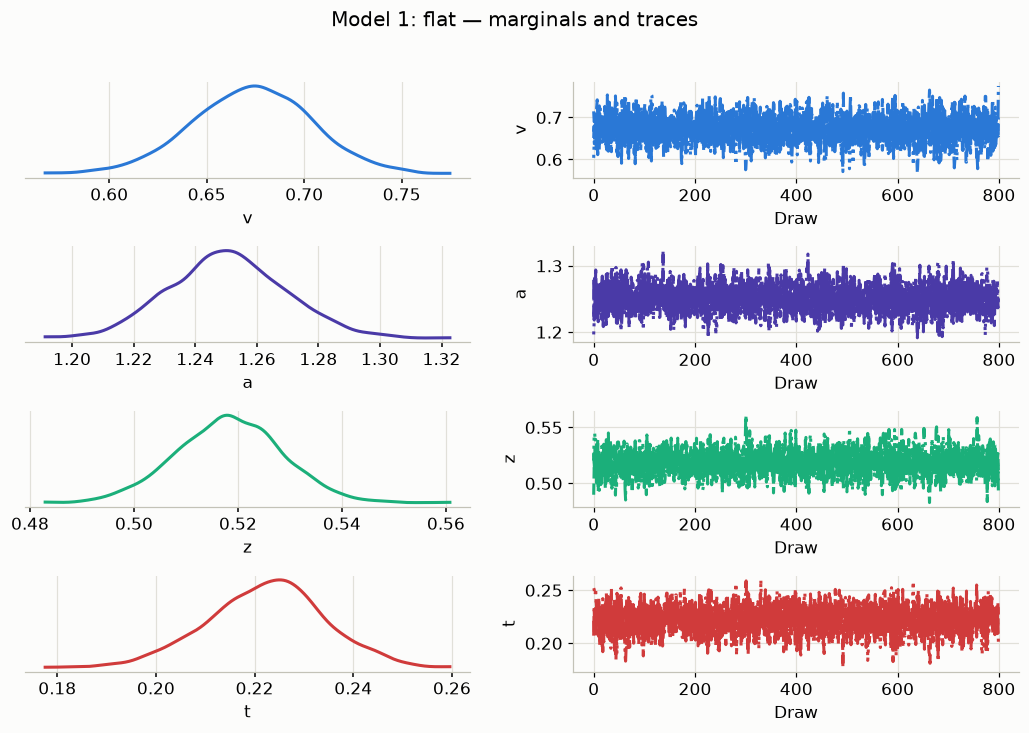

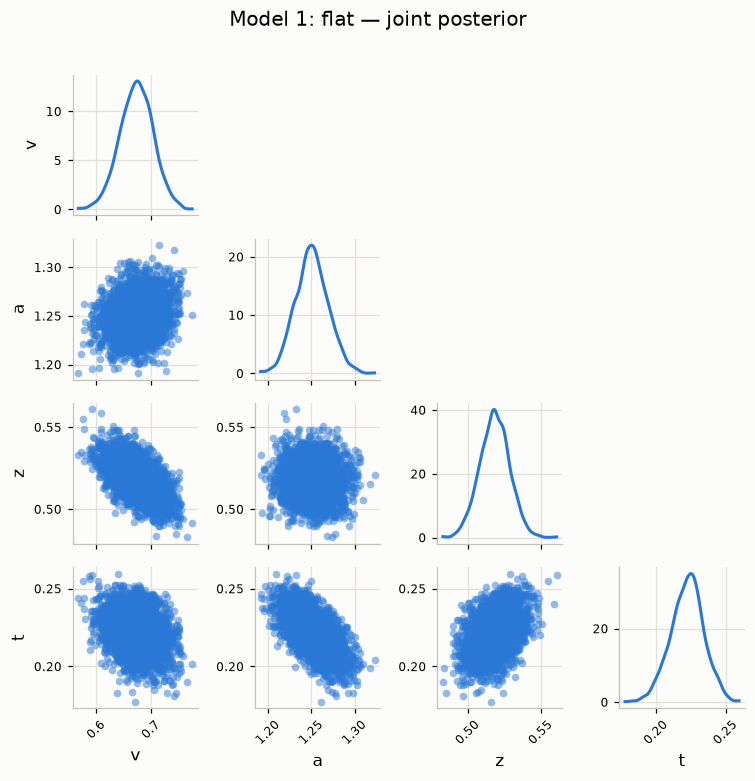

In [7]:
_ = S.posterior_diagnostics(idata_flat, PARAMS, title="Model 1: flat")

Clean caterpillars, overlapping chains, no red. The sampler did its job — the
model is a poor description of the data, which is a different problem and one
no amount of sampling fixes.

In the joint, notice `a` and `t` leaning against each other. Both push the RT
distribution to the right, so the data constrains their *combination* better
than either alone. That is the mild version of what Session 4 turns into a
real failure.

### A trap worth knowing about: where the likelihood goes flat

`t` is non-decision time — the part of the response that was never about
deciding. So `t` **cannot exceed the response time it is part of**. What does
the likelihood do if you ask it anyway?

It does not raise, and it does not return `-inf`. It returns a constant:

In [8]:
_probe = np.array([[0.5, 1.0]])                      # one trial, rt = 0.5 s
for _t in [0.10, 0.30, 0.49, 0.51, 0.70, 3.00]:
    # `logp_ddm` builds a *symbolic* pytensor expression rather than a number;
    # `.eval()` is what actually computes it.
    _lp = logp_ddm(_probe, v=1.0, a=1.2, z=0.5, t=_t).eval()  # ty: ignore[unresolved-attribute]
    print(f"t = {_t:4.2f}   log p = {float(np.ravel(_lp)[0]):9.3f}"
          + ("   <- impossible: t > rt" if _t > 0.5 else ""))

t = 0.10   log p =    -0.162
t = 0.30   log p =    -0.822
t = 0.49   log p =   -64.634
t = 0.51   log p =   -66.100   <- impossible: t > rt
t = 0.70   log p =   -66.100   <- impossible: t > rt
t = 3.00   log p =   -66.100   <- impossible: t > rt


Past `rt` the log-likelihood pins to `-66.1` and **stays there**. That region
is perfectly flat, and flat means *no gradient*. NUTS navigates by gradient,
so a chain that starts out there has nothing telling it which way is back. It
does not crash or warn — it wanders on the plateau for the entire run, and
because every trajectory runs to maximum tree depth, it is also very slow.

This is not hypothetical. Our fastest trial is:

In [9]:
# Ask the model where it *would* have started, rather than deriving it: PyMC
# picks a "support point" per distribution, and guessing which formula it uses
# is a good way to be confidently wrong.
_default_t = float(np.exp(m1_flat.initial_point()["t_log__"]))
print(f"fastest RT in the dataset : {data['rt'].min():.3f} s")
print(f"PyMC's default start for t: {_default_t:.3f} s   <- already past it")

fastest RT in the dataset : 0.365 s
PyMC's default start for t: 0.500 s   <- already past it


The default start sits **above the fastest RT**, i.e. inside the flat region.
Only the random jitter PyMC adds at initialisation rescues the chains that
happen to get pushed downward; the rest strand there for the whole run. That
is why `fit()` passes `initvals={"t": T_INIT}`.

Note *where* that goes: on `pm.sample`, not as `initval=` on the distribution.
They look interchangeable and are not — `initval=` marks the model as having
non-default initial values, and PyMC then refuses to compute a pointwise
log-likelihood for it, which breaks the `az.loo` comparison in section 4.

The general lesson is the one this whole section is about. **A stranded chain
produces a summary table that looks like a result.** You would catch it in
`r_hat`, and you would *see* it immediately in the pair plot — as a second
blob of draws, sitting somewhere no parameter value should be.


It sampled, it converged, and the numbers look perfectly reasonable. That is
the trap: **a model that fits nothing in particular still returns a tidy
answer.** You only find out by asking it to reproduce the data.

Sampling: [obs]


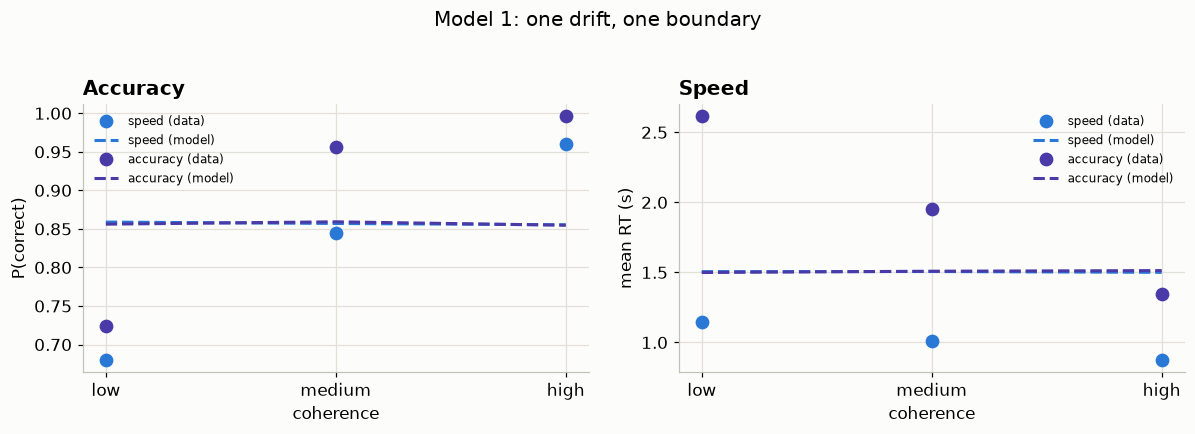

In [10]:
def cell_predictions(idata, model, n_keep=200):
    """Posterior-predictive accuracy and mean RT, per design cell.

    `pm.sample_posterior_predictive` has no `draws` argument: it regenerates the
    dataset once per posterior draw, all 3,200 of them. At 1,500 trials that is
    4.8 million simulated trials for a figure that needs a couple of hundred —
    about 95 seconds, against 8 for the fit itself.

    So thin the posterior BEFORE handing it over, not after. Slicing the `draw`
    axis is the whole fix, and it takes ~6 seconds instead.
    """
    post = idata.posterior.dataset
    n_draws = post.sizes["chain"] * post.sizes["draw"]
    step = max(1, n_draws // n_keep)
    thinned = idata.sel(draw=slice(None, None, step))

    with model:
        ppc = pm.sample_posterior_predictive(thinned, random_seed=RANDOM_SEED,
                                             progressbar=False)
    sim = ppc["posterior_predictive"].dataset["obs"].values   # (chain, draw, obs, 2)
    sim = sim.reshape(-1, sim.shape[-2], sim.shape[-1])
    out = []
    for coh in CONDITIONS:
        for emp in EMPHASES:
            mask = (data["coherence"] == coh) & (data["emphasis"] == emp)
            mask = mask.to_numpy()
            out.append({"coherence": coh, "emphasis": emp,
                        "accuracy": float((sim[:, mask, 1] == 1).mean()),
                        "mean_rt": float(sim[:, mask, 0].mean())})
    return pd.DataFrame(out).set_index(["coherence", "emphasis"])


pred_flat = cell_predictions(idata_flat, m1_flat)


def compare_plot(preds, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
    xx = np.arange(len(CONDITIONS))
    for emp, colour in [("speed", S.PRIMARY), ("accuracy", S.NAIVE)]:
        obs_s = summary.xs(emp, level="emphasis")
        pre_s = preds.xs(emp, level="emphasis")
        ax1.plot(xx, obs_s["accuracy"], "o", color=colour, ms=8, label=f"{emp} (data)")
        ax1.plot(xx, pre_s["accuracy"], "--", color=colour, label=f"{emp} (model)")
        ax2.plot(xx, obs_s["mean_rt"], "o", color=colour, ms=8, label=f"{emp} (data)")
        ax2.plot(xx, pre_s["mean_rt"], "--", color=colour, label=f"{emp} (model)")
    for ax, ylab, sub in [(ax1, "P(correct)", "Accuracy"), (ax2, "mean RT (s)", "Speed")]:
        ax.set(xticks=xx, xlabel="coherence", ylabel=ylab, title=sub)
        ax.set_xticklabels(CONDITIONS)
        ax.legend(fontsize=8)
    fig.suptitle(title, y=1.03)
    fig.tight_layout()


compare_plot(pred_flat, "Model 1: one drift, one boundary")

Circles are the data, dashed lines are the model. The model predicts **one
number per panel** — flat lines — because it has no way to know which cell a
trial came from. It splits the difference and gets everything wrong.

## 3. Your turn: propose a better model

You have four parameters and two design features. Let coherence and/or
emphasis act on whichever parameters you think should carry them.

In raw PyMC that is an index into a vector of parameters:

```python
with pm.Model(coords=COORDS) as m:
    v = pm.Normal("v", 0.0, 3.0, dims="coherence")   # one drift per level
    ...
    DDM("obs", v=v[coh_idx], a=a, z=z, t=t, observed=observed)
```

`coh_idx` is an integer per trial saying which coherence level it belongs to,
so `v[coh_idx]` is a per-trial drift rate. Nothing else changes.

**Spend five minutes.** Fit at least one alternative and look at its
predictions with `compare_plot`. Below are the two we will carry forward.

In [11]:
# Model 2: drift varies by coherence; one boundary for everyone.
with pm.Model(coords=COORDS) as m2_drift:
    # Priors
    v = pm.Normal("v", 0.0, 3.0, dims="coherence")
    a = pm.HalfNormal("a", 2.0)
    z = pm.Beta("z", 5.0, 5.0)
    t = pm.HalfNormal("t", 0.5)
    # Likelihood
    DDM("obs", v=v[coh_idx], a=a, z=z, t=t, observed=observed)

idata_drift = fit(m2_drift)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v, a, z, t]


Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 8 seconds.


             mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
v[low]      0.336  0.0377     0.28      0.4      2948      2288  1.00   0.00069  0.00049
v[medium]   0.846   0.045     0.78     0.92      2940      1871  1.01   0.00083  0.00058
v[high]      1.42   0.056      1.3      1.5      3367      2206  1.00   0.00097  0.00067
a          1.3165  0.0214      1.3      1.4      2854      2553  1.00    0.0004  0.00028
z          0.4873  0.0104     0.47      0.5      2456      2365  1.00   0.00021  0.00015
t           0.199   0.013     0.18     0.22      2373      2318  1.00   0.00027  0.00019


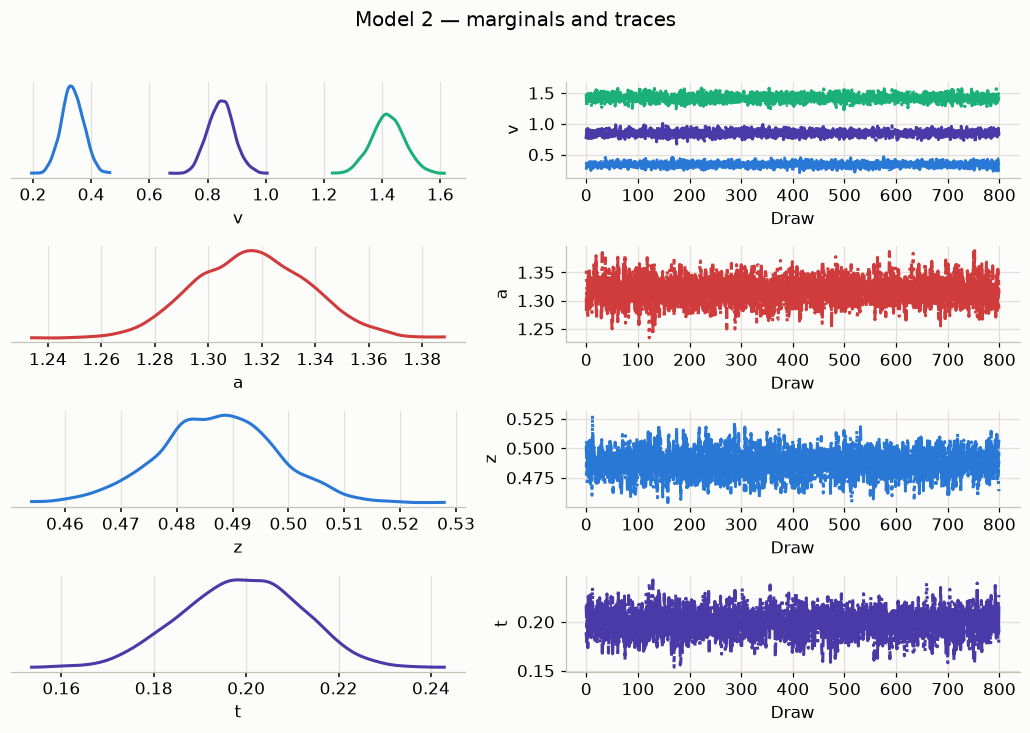

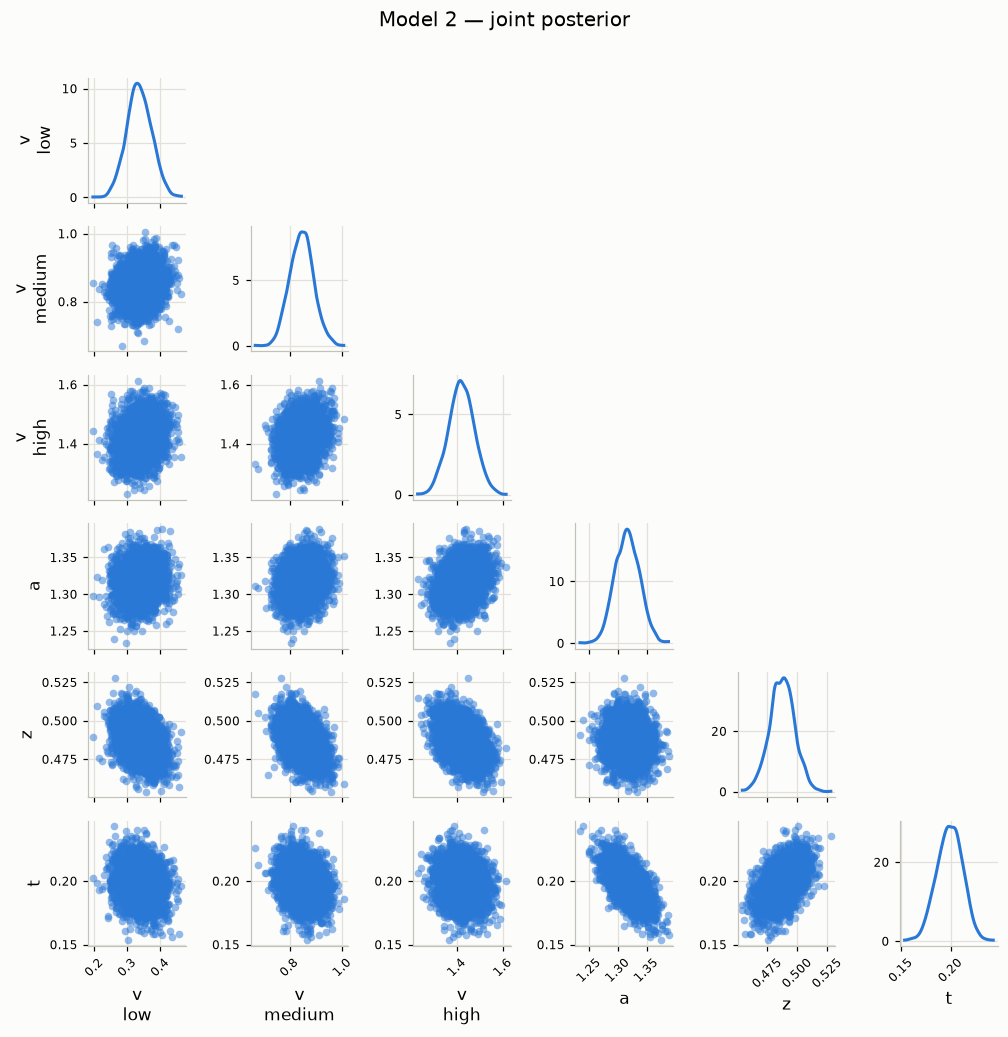

In [12]:
# Check the fit *before* looking at what it predicts: predictions drawn from a
# sampler that never converged are not predictions of anything.
print(az.summary(idata_drift, var_names=PARAMS, kind="all").to_string())
_ = S.posterior_diagnostics(idata_drift, PARAMS, title="Model 2")

Sampling: [obs]


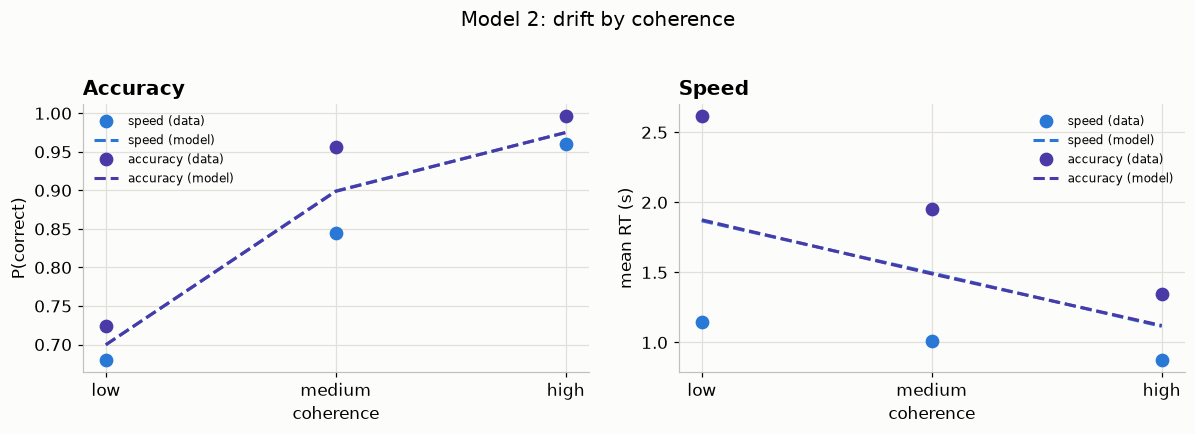

In [13]:
pred_drift = cell_predictions(idata_drift, m2_drift)
compare_plot(pred_drift, "Model 2: drift by coherence")

In [14]:
# Model 3: drift varies by coherence AND boundary varies by emphasis.
with pm.Model(coords=COORDS) as m3_both:
    # Priors
    v = pm.Normal("v", 0.0, 3.0, dims="coherence")
    a = pm.HalfNormal("a", 2.0, dims="emphasis")
    z = pm.Beta("z", 5.0, 5.0)
    t = pm.HalfNormal("t", 0.5)
    # Likelihood
    DDM("obs", v=v[coh_idx], a=a[emp_idx], z=z, t=t, observed=observed)

idata_both = fit(m3_both)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v, a, z, t]


Sampling 4 chains for 800 tune and 800 draw iterations (3_200 + 3_200 draws total) took 9 seconds.


               mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
v[low]        0.338  0.0394     0.27      0.4      4105      2664  1.00   0.00061  0.00044
v[medium]     0.895   0.047     0.82     0.97      3716      2741  1.00   0.00077  0.00055
v[high]        1.52   0.057      1.4      1.6      3457      2687  1.00   0.00097  0.00068
a[speed]     0.9471   0.019     0.92     0.98      3323      2401  1.00   0.00033  0.00023
a[accuracy]   1.624  0.0305      1.6      1.7      4063      2523  1.00   0.00049  0.00035
z            0.4985    0.01     0.48     0.51      2982      2604  1.00   0.00018  0.00013
t            0.2893  0.0085     0.28      0.3      3189      2131  1.00   0.00015  0.00011


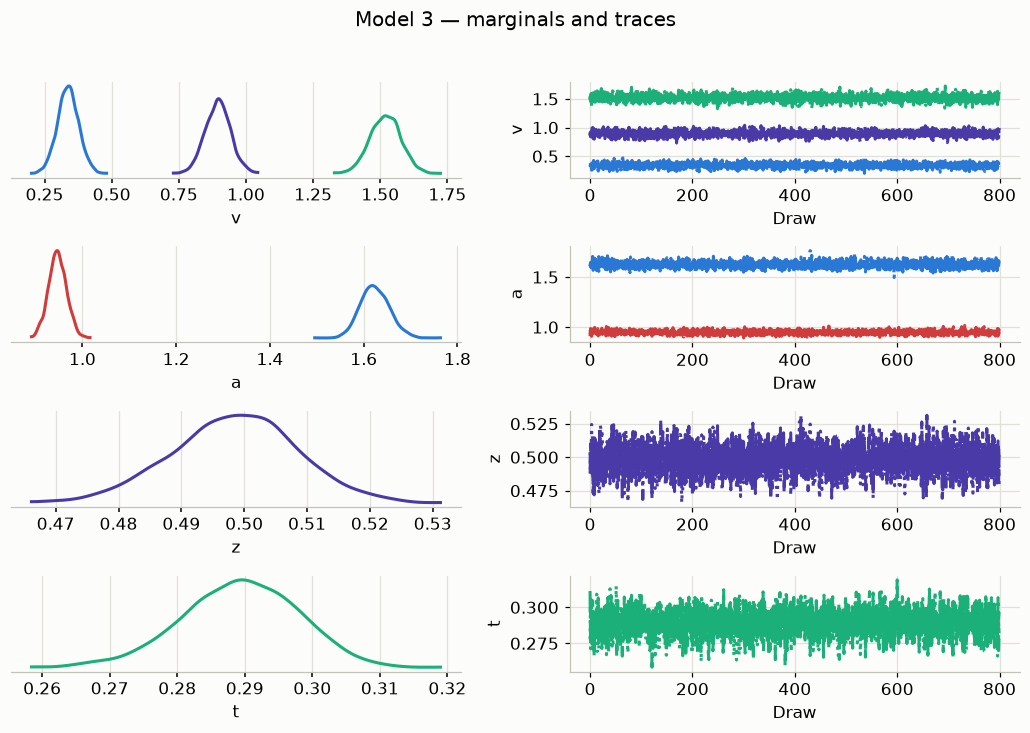

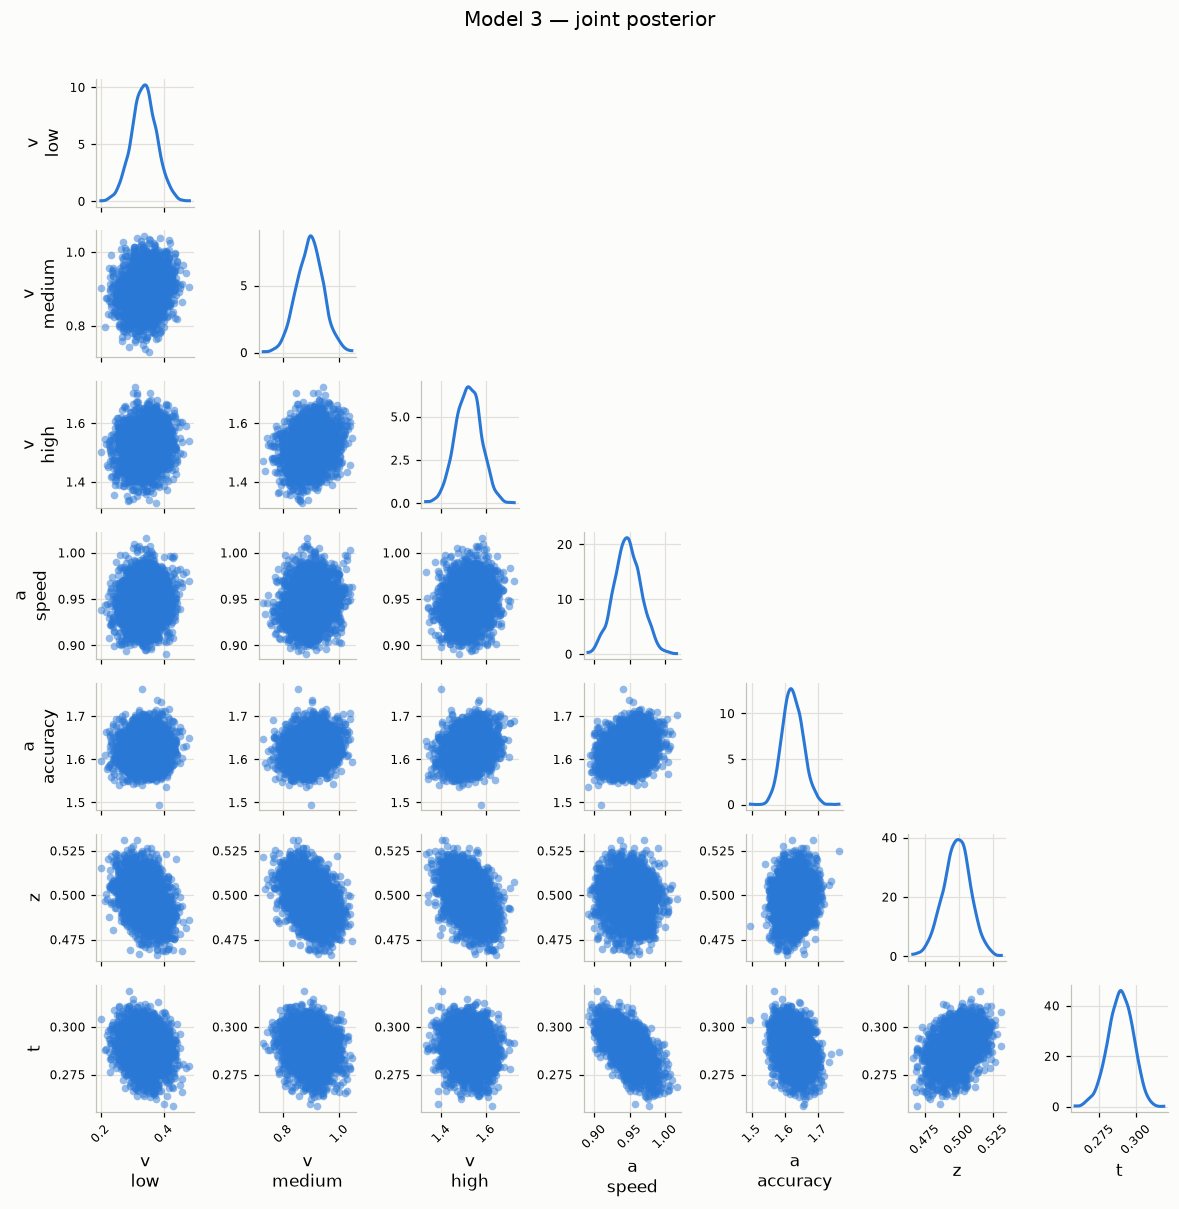

In [15]:
print(az.summary(idata_both, var_names=PARAMS, kind="all").to_string())
_ = S.posterior_diagnostics(idata_both, PARAMS, title="Model 3")

Sampling: [obs]


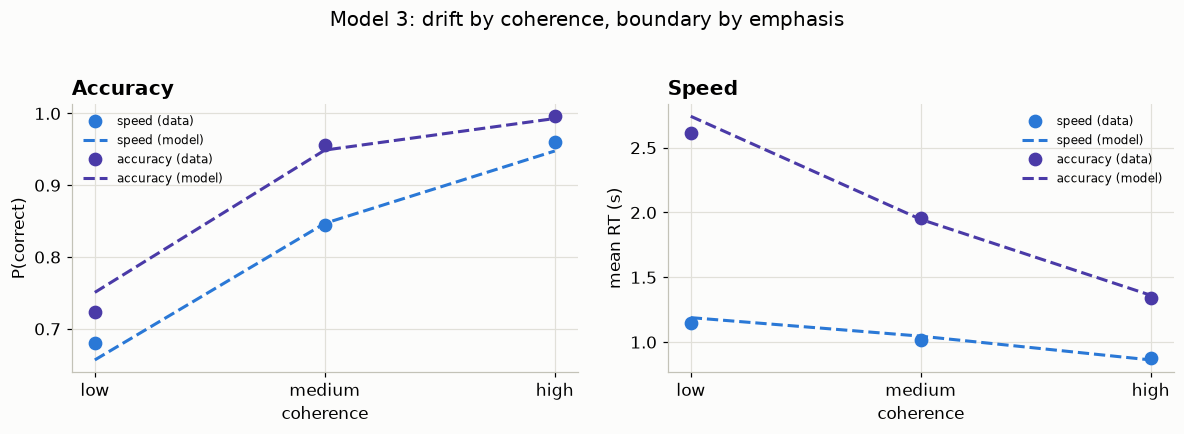

In [16]:
pred_both = cell_predictions(idata_both, m3_both)
compare_plot(pred_both, "Model 3: drift by coherence, boundary by emphasis")

Model 2 captures the accuracy pattern and still misses the RT pattern —
it has no way to separate the two emphasis conditions. Model 3 tracks both.

## 4. Comparing models properly

Eyeballing predictions is necessary but not sufficient: a model with more
parameters can always fit better. **Leave-one-out cross-validation** (LOO)
estimates out-of-sample predictive accuracy, so it penalises complexity that
does not pay for itself.

First, the transparent version: how far is each model's prediction from the
data, summed over the six design cells?

In [17]:
def discrepancy(preds):
    """Mean absolute error in predicted accuracy and mean RT, across cells."""
    joined = summary.join(preds, rsuffix="_pred")
    return pd.Series({
        "accuracy MAE": (joined["accuracy"] - joined["accuracy_pred"]).abs().mean(),
        "mean RT MAE": (joined["mean_rt"] - joined["mean_rt_pred"]).abs().mean(),
    })


preds_all = {"1: flat": pred_flat,
             "2: drift by coherence": pred_drift,
             "3: drift + boundary": pred_both}
print(pd.DataFrame({k: discrepancy(v) for k, v in preds_all.items()}).T
        .to_string(float_format=lambda v: f"{v:.4f}"))

                       accuracy MAE  mean RT MAE
1: flat                      0.1111       0.5344
2: drift by coherence        0.0320       0.4780
3: drift + boundary          0.0126       0.0399


That ranks the models but says nothing about **overfitting** — a model with
more parameters will generally track the data more closely whether or not the
extra flexibility is real. For that we want an estimate of *out-of-sample*
predictive accuracy. `az.loo` provides one via leave-one-out
cross-validation.

In [18]:
for name, idata in [("1: flat", idata_flat),
                    ("2: drift by coherence", idata_drift),
                    ("3: drift + boundary", idata_both)]:
    try:
        loo = az.loo(idata)
        k = loo.pareto_k.values
        bad = int((k > 0.7).sum())
        print(f"{name:24s} elpd_loo = {float(loo.elpd):9.1f}   "
              f"p_loo = {float(loo.p):6.1f}   Pareto k > 0.7: {bad:3d}/{k.size}")
    except Exception as exc:
        # `az.loo` can raise outright on a badly misspecified model. Catching it
        # per model means one casualty does not hide the rows that did work —
        # which is not true of `az.compare` below.
        print(f"{name:24s} LOO FAILED: {type(exc).__name__}: {exc}")

1: flat                  elpd_loo =   -2265.0   p_loo =    4.7   Pareto k > 0.7:   0/1500


2: drift by coherence    elpd_loo =   -2102.3   p_loo =    6.2   Pareto k > 0.7:   0/1500


3: drift + boundary      elpd_loo =   -1838.4   p_loo =    7.4   Pareto k > 0.7:   0/1500


<details class="sbi-warn" open>
<summary>⚠️ <b>Read the Pareto <i>k</i> column before the elpd column</b></summary>

LOO does not refit the model 1500 times; it *reweights* the existing draws,
and that shortcut only works when no single observation dominates the weights.
The Pareto $k$ diagnostic detects when it fails, and values above about 0.7
mean the estimate for that point is not to be trusted.

Here every one of the 1500 points clears that bar for all three models, so the
`elpd_loo` column is worth reading. This is the *good* case, and it is worth
seeing once so that you recognise the bad one.

Now the uncomfortable part. **Model 1 is visibly wrong** — you just watched it
miss the accuracy pattern and the RT pattern in every one of the six cells.
Its diagnostics are nonetheless immaculate: a `p_loo` of about 4.7 for a model
with four parameters, which is exactly right, and not one bad $k$.

A clean Pareto $k$ column does **not** say the model is any good. It says LOO
managed to compute its own estimate reliably. Those are different claims, and
only the second one is being made.

So: use LOO to separate *plausible* models from each other, and use posterior
predictive plots to reject the implausible ones. Do not ask LOO to rank a
model that the plots already told you is wrong.

</details>

### Is that gap big enough to believe?

The loop ranks the models but leaves open the question a reviewer would
actually ask: model 3 beats model 2 by a couple of hundred `elpd` — is that
decisive, or is it noise? **`az.compare` answers exactly that**, and it is the
call you would reach for in practice rather than the loop above.

In [19]:
comparison = az.compare(
    {"1: flat": idata_flat,
     "2: drift by coherence": idata_drift,
     "3: drift + boundary": idata_both},
    # The default reference is the BEST model, so every difference comes out
    # negative. Pointing it at the baseline instead matches the 1 -> 2 -> 3
    # story we have been telling. `reference=` is new in ArviZ 1.x.
    reference="1: flat",
)
print(comparison)

                       rank  elpd_diff   dse  p_better diag_diff diag_elpd  \
3: drift + boundary       0      430.0  28.0       1.0                       
2: drift by coherence     1      160.0  18.0       1.0                       
1: flat                   2        0.0   0.0       NaN                       

                         p    elpd    se  weight  
3: drift + boundary    7.4 -1840.0  49.0     1.0  
2: drift by coherence  6.2 -2100.0  51.0     0.0  
1: flat                4.7 -2300.0  55.0     0.0  


The column that earns this call is **`dse`** — the standard error of the
*difference*. Model 3 improves on the baseline by roughly 430, with a `dse`
around 28: about fifteen standard errors, so nothing about that ordering is in
doubt. Model 2's smaller gain clears its own `dse` just as comfortably.

Notice that `dse` is **not** something you could have reconstructed from the
`se` column beside it. Each model's own `elpd` carries a standard error near
50, yet the *difference* between two of them is pinned down to 18–28 — a
smaller uncertainty than either individual number. That is not a
contradiction. The models are scored on the **same 1500 observations**, so
their errors are strongly correlated, and `compare` takes the difference
**pointwise, per observation**, before summing. Whatever the two models find
equally hard cancels out, and only the disagreement is left to be uncertain
about.

This is why "the intervals overlap, so the models are indistinguishable" is
the wrong reading of a comparison table. Read `elpd_diff` against `dse`, never
`elpd` against `se`.

`weight` is the third thing worth a glance: these are stacking weights, the
blend that would predict best. Model 3 takes all of it, so there is nothing to
gain here from averaging the candidates together.

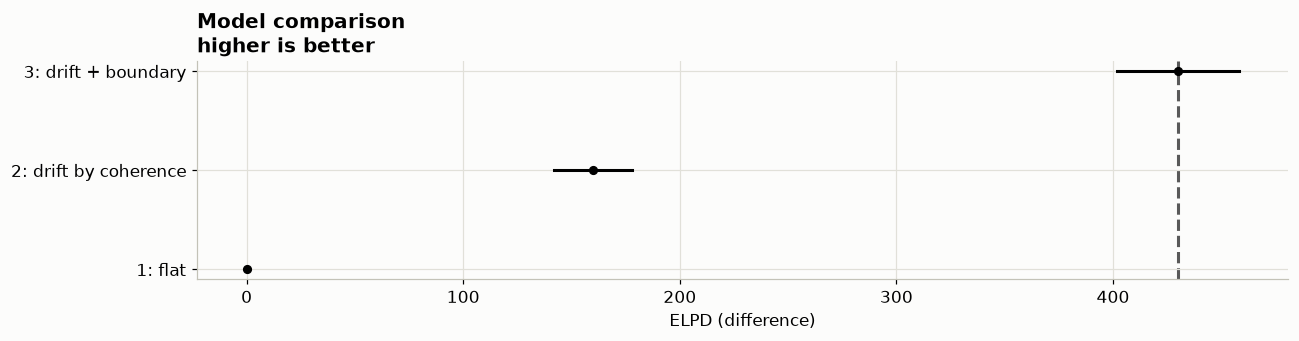

In [20]:
# `plot_compare` returns a PlotCollection. Assign it — letting it be the cell's
# value prints `<arviz_plots.plot_collection.PlotCollection at 0x...>` above the
# figure.
_ = az.plot_compare(comparison)

<details class="sbi-note">
<summary>📝 <b>Two practical notes on <code>az.compare</code></b></summary>

**It is all-or-nothing.** If LOO cannot be computed for *one* model, the whole
call raises (`Encountered error trying to compute ELPD from model ...`) and
you get no table at all. That is why the loop above catches per model: on a
set of candidates where one is badly misspecified, the loop still shows you
the rows that worked. Run the loop first, then `compare`.

**It accepts already-computed results.** The dictionary takes either fits or
`ELPDData` objects, so `az.compare({name: loo_result, ...})` reuses the
`az.loo` calls you have already paid for instead of repeating them.

</details>

## 5. What actually generated the data

Time to look behind the curtain.

In [21]:
print("TRUE generating parameters")
print("  drift by coherence :", _V_BY_COHERENCE)
print("  boundary by emphasis:", _A_BY_EMPHASIS)
print(f"  start point z = {_Z_TRUE},  non-decision time t = {_T_TRUE}\n")

post = idata_both.posterior.dataset
print("Model 3 recovery")
for i, coh in enumerate(CONDITIONS):
    est = post["v"].values[..., i]
    print(f"  v[{coh:<6}] {est.mean():5.2f} +/- {est.std():.2f}"
          f"   (true {_V_BY_COHERENCE[coh]})")
for i, emp in enumerate(EMPHASES):
    est = post["a"].values[..., i]
    print(f"  a[{emp:<8}] {est.mean():5.2f} +/- {est.std():.2f}"
          f" (true {_A_BY_EMPHASIS[emp]})")
print(f"  z          {post['z'].values.mean():5.2f} +/- {post['z'].values.std():.2f}"
      f"   (true {_Z_TRUE})")
print(f"  t          {post['t'].values.mean():5.2f} +/- {post['t'].values.std():.2f}"
      f"   (true {_T_TRUE})")

TRUE generating parameters
  drift by coherence : {'low': 0.35, 'medium': 0.85, 'high': 1.5}
  boundary by emphasis: {'speed': 0.9, 'accuracy': 1.6}
  start point z = 0.5,  non-decision time t = 0.3

Model 3 recovery
  v[low   ]  0.34 +/- 0.04   (true 0.35)
  v[medium]  0.90 +/- 0.05   (true 0.85)
  v[high  ]  1.52 +/- 0.06   (true 1.5)
  a[speed   ]  0.95 +/- 0.02 (true 0.9)
  a[accuracy]  1.62 +/- 0.03 (true 1.6)
  z           0.50 +/- 0.01   (true 0.5)
  t           0.29 +/- 0.01   (true 0.3)


Model 3 **is** the generating model, and it recovers the parameters. That is
the happy case, and it is worth being explicit about why it went well:

- the design has enough trials per cell,
- the manipulations act on **different** parameters, so they do not compete,
- and the error rates are moderate, which we will discover in half an hour is
  not a small thing.

<details class="sbi-warn" open>
<summary>⚠️ <b>The comparison found the right model. It could not have told you it was <i>correct</i>.</b></summary>

LOO ranks the candidates **you** proposed. If the true model is not among
them, comparison happily hands you the best of a bad set, with no hint that
anything is missing. That is what posterior predictive plots are for — they
compare a model against the *data*, not against its rivals. Use both.

</details>

### Exercise

Fit a fourth model in which **coherence acts on the boundary** and
**emphasis acts on the drift** — the mapping deliberately swapped. Add it to
the comparison.

Predict first: will it fit better or worse than model 1? Than model 3?

<details>
<summary>Solution and what to notice</summary>

```python
with pm.Model(coords=COORDS) as m4_swapped:
    v = pm.Normal("v", 0.0, 3.0, dims="emphasis")
    a = pm.HalfNormal("a", 2.0, dims="coherence")
    z = pm.Beta("z", 5.0, 5.0)
    t = pm.HalfNormal("t", 0.5)
    DDM("obs", v=v[emp_idx], a=a[coh_idx], z=z, t=t, observed=observed)

idata_swapped = fit(m4_swapped)
for nm, idt in [("3: drift + boundary", idata_both), ("4: swapped", idata_swapped)]:
    loo = az.loo(idt)
    print(f"{nm:22s} elpd_loo = {float(loo.elpd):9.1f}")
compare_plot(cell_predictions(idata_swapped, m4_swapped), "Model 4: swapped")
```

It fits **much better than model 1** — it has the same number of parameters
as model 3 and can bend both curves, so it soaks up a lot of the structure.
It fits **worse than model 3**, and the predictive plot shows why: it can
make accuracy depend on emphasis and RT depend on coherence, which is the
wrong way round, so it cannot reproduce both patterns at once.

The lesson is that "more flexible" and "right" are different things. A model
can have exactly the right number of parameters, fit far better than nothing,
and still be telling you a false story about the mechanism.

</details>


### Where this goes

Writing `v[coh_idx]` by hand gets old quickly. On **Day 3 at 09:30** the same
model is one line:

```python
hssm.HSSM(data=data, model="ddm",
          include=[{"name": "v", "formula": "v ~ 0 + C(coherence)"},
                   {"name": "a", "formula": "a ~ 0 + C(emphasis)"}])
```

**Next, at 15:00:** we stop assuming the sampler works. Everything today
converged quietly — that is not guaranteed, and the failures are more
interesting than the successes.